In [29]:
import requests
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing

In [2]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

/var/folders/cb/61f4dr4x06v372b0m7m0wmv80000gn/T/ipykernel_39317/3291602058.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [3]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [6]:
T90=np.array(data[6],dtype=float)
T90_err=np.array(data[7],dtype=float)
fluence=np.array(data[9],dtype=float)
print(T90)
print(fluence)

[-999.      10.24  -999.    ...    3.136  208.576    5.184]
[-9.9900e+02  2.5096e-06 -9.9900e+02 ...  2.4858e-08  1.6510e-07
  2.6055e-06]


picco a -999 = flag

(array([1.129e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

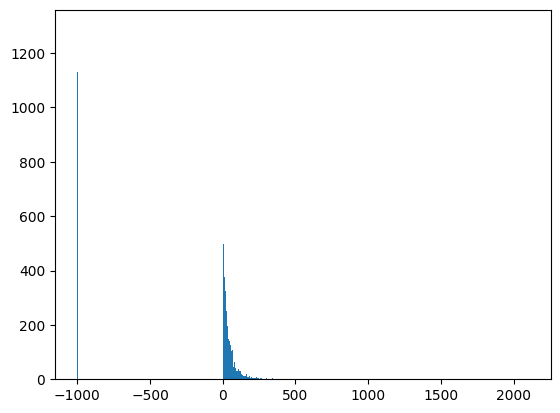

In [7]:
plt.hist(T90, bins=1000)

In [8]:
data_new2=np.column_stack((T90,fluence))

In [9]:
data_new2

array([[-9.99000e+02, -9.99000e+02],
       [ 1.02400e+01,  2.50960e-06],
       [-9.99000e+02, -9.99000e+02],
       ...,
       [ 3.13600e+00,  2.48580e-08],
       [ 2.08576e+02,  1.65100e-07],
       [ 5.18400e+00,  2.60550e-06]], shape=(8721, 2))

In [10]:
mask2 = ~(data_new2 == -999).any(axis=1)
data_clean2= data_new2[mask2]
data_clean2

array([[1.02400e+01, 2.50960e-06],
       [2.27840e+01, 3.80160e-05],
       [1.10080e+01, 1.12930e-06],
       ...,
       [3.13600e+00, 2.48580e-08],
       [2.08576e+02, 1.65100e-07],
       [5.18400e+00, 2.60550e-06]], shape=(7503, 2))

In [16]:
T90

array([ 10.24 ,  22.784,  11.008, ...,   3.136, 208.576,   5.184],
      shape=(7503,))

In [18]:
T90

array([ 10.24 ,  22.784,  11.008, ...,   3.136, 208.576,   5.184],
      shape=(7503,))

In [19]:
data_clean2

array([[1.02400e+01, 2.50960e-06],
       [2.27840e+01, 3.80160e-05],
       [1.10080e+01, 1.12930e-06],
       ...,
       [3.13600e+00, 2.48580e-08],
       [2.08576e+02, 1.65100e-07],
       [5.18400e+00, 2.60550e-06]], shape=(7503, 2))

## Clustering con K-means

In [47]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(data_clean2)

centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(data_clean2) #labels for each of the points

In [48]:
labels.shape

(7503,)

In [49]:
centers

array([[2.88433685e+01, 1.14336532e-05],
       [2.53794818e+02, 1.11255223e-04]])

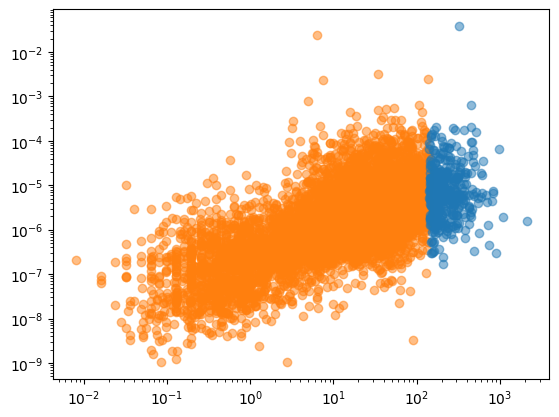

In [50]:
# plot the data color-coded by cluster id
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(data_clean2[labels==ii,0], data_clean2[labels==ii,1], color=colors[ii],alpha=0.5)
plt.yscale('log')
plt.xscale('log')


## Clustering con MeanShift

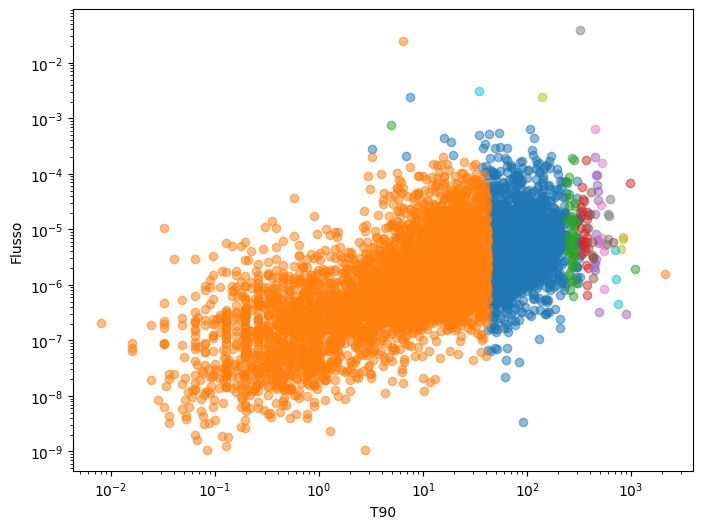

In [51]:
# Normalizza i dati
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(data_clean2)

# Applica MeanShift
ms = MeanShift(bandwidth=0.4, bin_seeding=True, cluster_all=False)
ms.fit(X_scaled)

# Estrai i cluster e i centroids
labels_ms = ms.labels_
centers_ms = ms.cluster_centers_

# Visualizza il clustering
plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels_ms)
for label in unique_labels:
    plt.scatter(data_clean2[labels_ms == label, 0], data_clean2[labels_ms == label, 1], 
                alpha=0.5, label=f'Cluster {label+1}')


plt.xlabel('T90')
plt.ylabel('Flusso')
plt.yscale('log')
plt.xscale('log')

In [52]:
print("Number of estimated clusters:", n_clusters)

Number of estimated clusters: 22
